# Huffman Coding: Greedy Compression

Huffman coding compresses text without losing information.

David Huffman created the algorithm in 1952 as a student, solving a coding problem so cleanly that it became a standard example of greedy design. Its descendants and related prefix-code ideas show up in file compression, image formats, network protocols, and storage systems.

The trick:

> frequent characters get short bit codes, rare characters get longer bit codes.

This is why it is a classic greedy algorithm. At every step, it merges the two least frequent pieces first.

## 1. Mental Model

Imagine each character starts as a tiny tree labeled with its frequency.

Then repeat:

1. pick the two lightest trees,
2. merge them into a new tree,
3. put that merged tree back in the pile.

When only one tree remains, each left/right path becomes a binary code.

<details>
<summary>Why this saves space</summary>

In normal ASCII, every character costs 8 bits. Huffman coding lets common characters use fewer than 8 bits, while rare characters pay the longer-code cost.
</details>

## 2. Build the Objects

We will use:

- `HuffmanNode`: one leaf or internal tree node,
- `MergeStep`: one greedy merge operation,
- `CodeEntry`: one character's frequency and code,
- `CompressionReport`: the final encoded text, decoded text, and savings,
- `HuffmanCoder`: the object that builds the tree and uses it.

The tree is the codebook. Left edges become `0`, right edges become `1`.

**Imports and setup.** Load the libraries and shared tools used by the lesson.


In [ ]:
from __future__ import annotations

from collections import Counter

from dataclasses import dataclass

from heapq import heappop, heappush

from itertools import count

import matplotlib.pyplot as plt


**Object model.** Define `HuffmanNode`, the named objects used by the next examples.


In [ ]:
from __future__ import annotations

@dataclass(frozen=True)
class HuffmanNode:
    weight: int
    symbol: str | None = None
    left: HuffmanNode | None = None
    right: HuffmanNode | None = None

    def is_leaf(self) -> bool:
        return self.symbol is not None

    def symbols(self) -> str:
        if self.is_leaf():
            return self.symbol
        return "".join(sorted((self.left.symbols() if self.left else "") + (self.right.symbols() if self.right else "")))

    def display_label(self) -> str:
        if self.is_leaf():
            return f"{repr(self.symbol)}\n{self.weight}"
        symbols = self.symbols()
        preview = symbols if len(symbols) <= 8 else symbols[:8] + "..."
        return f"{preview}\n{self.weight}"


**Trace model.** Define `MergeStep`, the structure used to capture replayable algorithm state.


In [ ]:
from __future__ import annotations

@dataclass(frozen=True)
class MergeStep:
    step_number: int
    left_symbols: str
    left_weight: int
    right_symbols: str
    right_weight: int
    merged_weight: int

    def summary(self) -> str:
        return (
            f"step {self.step_number}: merge "
            f"{self.left_symbols!r} ({self.left_weight}) + "
            f"{self.right_symbols!r} ({self.right_weight}) -> {self.merged_weight}"
        )


**Object model.** Define `CodeEntry`, the named objects used by the next examples.


In [ ]:
from __future__ import annotations

@dataclass(frozen=True)
class CodeEntry:
    symbol: str
    frequency: int
    code: str

    @property
    def huffman_bits(self) -> int:
        return self.frequency * len(self.code)

    @property
    def ascii_bits(self) -> int:
        return self.frequency * 8

    def printable_symbol(self) -> str:
        if self.symbol == " ":
            return "space"
        if self.symbol == "\n":
            return "newline"
        return self.symbol


**Object model.** Define `CompressionReport`, the named objects used by the next examples.


In [ ]:
from __future__ import annotations

@dataclass(frozen=True)
class CompressionReport:
    text: str
    root: HuffmanNode
    frequencies: Counter[str]
    codes: dict[str, str]
    encoded_bits: str
    decoded_text: str
    merge_steps: list[MergeStep]

    @property
    def ascii_bits(self) -> int:
        return len(self.text) * 8

    @property
    def huffman_bits(self) -> int:
        return len(self.encoded_bits)

    @property
    def saved_bits(self) -> int:
        return self.ascii_bits - self.huffman_bits

    @property
    def percent_saved(self) -> float:
        return 100 * self.saved_bits / self.ascii_bits

    def code_table(self) -> list[CodeEntry]:
        entries = [
            CodeEntry(symbol=symbol, frequency=frequency, code=self.codes[symbol])
            for symbol, frequency in self.frequencies.items()
        ]
        return sorted(entries, key=lambda entry: (-entry.frequency, len(entry.code), entry.symbol))

    def summary(self) -> str:
        return (
            f"characters: {len(self.text)}\n"
            f"unique symbols: {len(self.frequencies)}\n"
            f"ASCII bits: {self.ascii_bits}\n"
            f"Huffman bits: {self.huffman_bits}\n"
            f"saved bits: {self.saved_bits}\n"
            f"space saved: {self.percent_saved:.2f}%\n"
            f"lossless check: {self.decoded_text == self.text}"
        )


**Object model.** Define `HuffmanCoder`, the named objects used by the next examples.


In [ ]:
from __future__ import annotations

class HuffmanCoder:
    def build(self, text: str) -> CompressionReport:
        if not text:
            raise ValueError("Huffman coding needs at least one character")

        frequencies = Counter(text)
        root, merge_steps = self.build_tree(frequencies)
        codes = self.build_codes(root)
        encoded_bits = self.encode(text, codes)
        decoded_text = self.decode(encoded_bits, root)
        return CompressionReport(text, root, frequencies, codes, encoded_bits, decoded_text, merge_steps)

    def build_tree(self, frequencies: Counter[str]) -> tuple[HuffmanNode, list[MergeStep]]:
        serial = count()
        heap: list[tuple[int, int, HuffmanNode]] = []

        for symbol, frequency in sorted(frequencies.items()):
            heappush(heap, (frequency, next(serial), HuffmanNode(frequency, symbol=symbol)))

        if len(heap) == 1:
            _, _, only_node = heap[0]
            return HuffmanNode(only_node.weight, left=only_node), []

        merge_steps: list[MergeStep] = []
        while len(heap) > 1:
            left_weight, _, left = heappop(heap)
            right_weight, _, right = heappop(heap)
            parent = HuffmanNode(left_weight + right_weight, left=left, right=right)

            merge_steps.append(
                MergeStep(
                    step_number=len(merge_steps) + 1,
                    left_symbols=left.symbols(),
                    left_weight=left_weight,
                    right_symbols=right.symbols(),
                    right_weight=right_weight,
                    merged_weight=parent.weight,
                )
            )
            heappush(heap, (parent.weight, next(serial), parent))

        return heap[0][2], merge_steps

    def build_codes(self, root: HuffmanNode) -> dict[str, str]:
        codes: dict[str, str] = {}

        def walk(node: HuffmanNode, prefix: str) -> None:
            if node.is_leaf():
                codes[node.symbol] = prefix or "0"
                return
            if node.left is not None:
                walk(node.left, prefix + "0")
            if node.right is not None:
                walk(node.right, prefix + "1")

        walk(root, "")
        return codes

    def encode(self, text: str, codes: dict[str, str]) -> str:
        return "".join(codes[symbol] for symbol in text)

    def decode(self, encoded_bits: str, root: HuffmanNode) -> str:
        decoded: list[str] = []
        node = root

        for bit in encoded_bits:
            node = node.left if bit == "0" else node.right
            if node is None:
                raise ValueError("encoded bit stream does not match this tree")
            if node.is_leaf():
                decoded.append(node.symbol)
                node = root

        return "".join(decoded)


**Visual helper.** Define `draw_huffman_tree`, which turns state into something students can inspect.


In [ ]:
from __future__ import annotations

def draw_huffman_tree(root: HuffmanNode) -> None:
    positions: dict[int, tuple[float, float]] = {}
    labels: dict[int, str] = {}
    edges: list[tuple[int, int, str]] = []
    leaf_counter = count()

    def place(node: HuffmanNode, depth: int) -> float:
        node_id = id(node)
        labels[node_id] = node.display_label()
        if node.is_leaf():
            x_position = float(next(leaf_counter))
        else:
            child_positions: list[float] = []
            if node.left is not None:
                left_x = place(node.left, depth + 1)
                child_positions.append(left_x)
                edges.append((node_id, id(node.left), "0"))
            if node.right is not None:
                right_x = place(node.right, depth + 1)
                child_positions.append(right_x)
                edges.append((node_id, id(node.right), "1"))
            x_position = sum(child_positions) / len(child_positions)
        positions[node_id] = (x_position, -depth)
        return x_position

    place(root, 0)

    fig, ax = plt.subplots(figsize=(12, 6))
    for parent_id, child_id, bit in edges:
        parent_x, parent_y = positions[parent_id]
        child_x, child_y = positions[child_id]
        ax.plot([parent_x, child_x], [parent_y, child_y], color="#555555", linewidth=1.5)
        ax.text((parent_x + child_x) / 2, (parent_y + child_y) / 2, bit, color="#D95D39", fontsize=11, weight="bold")

    for node_id, (x_position, y_position) in positions.items():
        ax.scatter(x_position, y_position, s=900, color="#F6D55C", edgecolor="#1F2933", linewidth=1.2, zorder=3)
        ax.text(x_position, y_position, labels[node_id], ha="center", va="center", fontsize=8, zorder=4)

    ax.set_title("Huffman tree: left = 0, right = 1")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


## 3. Compress a Public-Domain Text Sample

This sample uses a short excerpt from *Alice's Adventures in Wonderland* by Lewis Carroll.

Swap `sample_text` with a longer public-domain chapter and rerun the cells. The same code will calculate the exact bit savings.

In [2]:
from __future__ import annotations

sample_text = """
Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do: once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, 'and what
is the use of a book,' thought Alice 'without pictures or conversation?'

So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a
daisy-chain would be worth the trouble of getting up and picking the daisies,
when suddenly a White Rabbit with pink eyes ran close by her.
""".strip()

report = HuffmanCoder().build(sample_text)
print(report.summary())
print()
print("encoded preview:")
print(report.encoded_bits[:160] + "...")

characters: 591
unique symbols: 34
ASCII bits: 4728
Huffman bits: 2557
saved bits: 2171
space saved: 45.92%
lossless check: True

encoded preview:
0101010111001110101101100011110000100010100111110001001110111101001110111101001111101111111011100011111011100110111111001011001110101001001111011101011010001100...


## 4. Inspect the Codebook

The codebook is where compression becomes visible. Common symbols should usually have shorter codes.

**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
from __future__ import annotations

entries = report.code_table()

print(f"{'symbol':<8} {'freq':>5} {'code':<14} {'bits saved vs ASCII':>20}")

print("-" * 52)

for entry in entries[:16]:
    saved = entry.ascii_bits - entry.huffman_bits
    print(f"{entry.printable_symbol():<8} {entry.frequency:>5} {entry.code:<14} {saved:>20}")

popular_entries = entries[:12]

labels = [entry.printable_symbol() for entry in popular_entries]

frequencies = [entry.frequency for entry in popular_entries]

code_lengths = [len(entry.code) for entry in popular_entries]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, frequencies, color="#3CAEA3")

axes[0].set_title("most common symbols")

axes[0].set_ylabel("frequency")

axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(labels, code_lengths, color="#F6D55C", edgecolor="#1F2933")

axes[1].axhline(8, color="#D95D39", linestyle="--", label="ASCII length")

axes[1].set_title("Huffman code length")

axes[1].set_ylabel("bits per symbol")

axes[1].tick_params(axis="x", rotation=45)

axes[1].legend()

plt.tight_layout()


**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
from __future__ import annotations

plt.show()


## 5. Watch the Greedy Merges

Huffman coding is greedy because it always combines the two lightest available trees.

That local choice builds a globally efficient prefix code.

In [5]:
from __future__ import annotations

class MergeReplay:
    def __init__(self, report: CompressionReport):
        self.report = report

    def show(self, first: int = 8, last: int = 5) -> None:
        steps = self.report.merge_steps
        if len(steps) <= first + last:
            for step in steps:
                print(step.summary())
            return

        for step in steps[:first]:
            print(step.summary())

        skipped = len(steps) - first - last
        print(f"... skipped {skipped} middle merges ...")

        for step in steps[-last:]:
            print(step.summary())


MergeReplay(report).show()

step 1: merge '-' (1) + '.' (1) -> 2
step 2: merge ':' (1) + '?' (1) -> 2
step 3: merge 'R' (1) + 'S' (1) -> 2
step 4: merge 'W' (1) + 'A' (2) -> 3
step 5: merge '-.' (2) + ':?' (2) -> 4
step 6: merge 'RS' (2) + 'm' (3) -> 5
step 7: merge 'AW' (3) + "'" (4) -> 7
step 8: merge '-.:?' (4) + 'v' (5) -> 9
... skipped 20 middle merges ...
step 29: merge '-.:?dovy' (75) + 'it' (80) -> 155
step 30: merge 'RSbcgklmpr' (95) + ' ' (104) -> 199
step 31: merge 'aeuw' (111) + "\n',AWfhns" (126) -> 237
step 32: merge '-.:?diotvy' (155) + ' RSbcgklmpr' (199) -> 354
step 33: merge "\n',AWaefhnsuw" (237) + ' -.:?RSbcdgiklmoprtvy' (354) -> 591


## 6. Visualize a Small Huffman Tree

The full Alice sample has many symbols, so the complete tree is wide.

For the diagram, use a small phrase. The same algorithm builds both trees.

small phrase codebook:
i      freq=5  code=11
s      freq=4  code=00
p      freq=2  code=010
r      freq=2  code=011
space  freq=1  code=1000
e      freq=1  code=1001
m      freq=1  code=1010
v      freq=1  code=1011

characters: 17
unique symbols: 8
ASCII bits: 136
Huffman bits: 46
saved bits: 90
space saved: 66.18%
lossless check: True


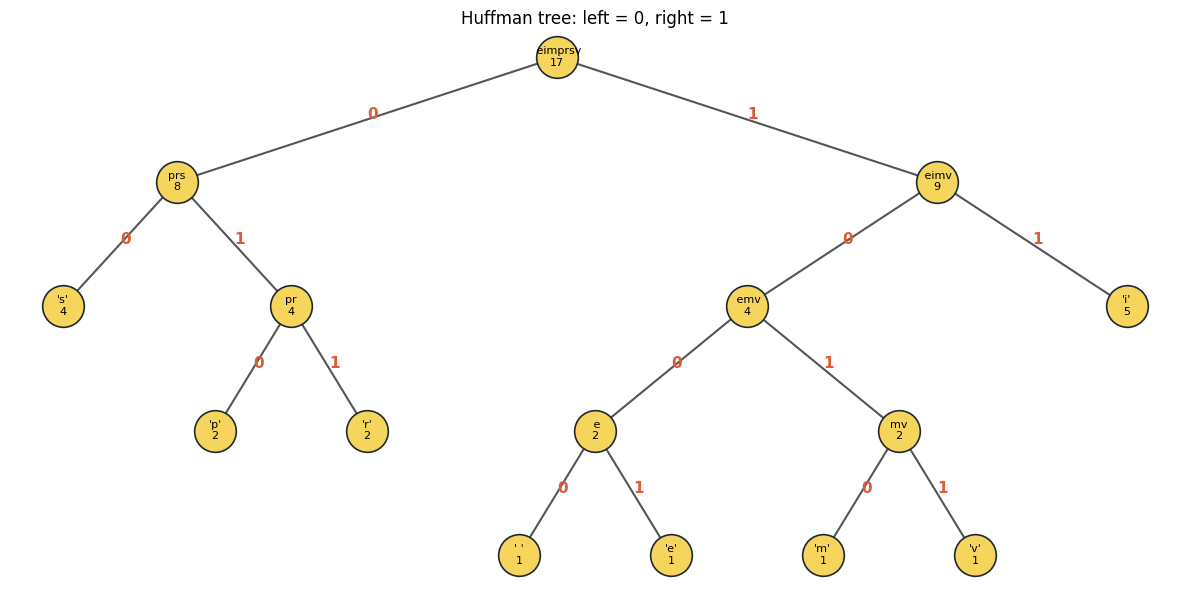

In [6]:
from __future__ import annotations

small_report = HuffmanCoder().build("mississippi river")

print("small phrase codebook:")
for entry in small_report.code_table():
    print(f"{entry.printable_symbol():<6} freq={entry.frequency:<2} code={entry.code}")
print()
print(small_report.summary())

draw_huffman_tree(small_report.root)

## 7. Bit Budget: ASCII vs Huffman

This is the payoff: same message, fewer bits, no lost information.

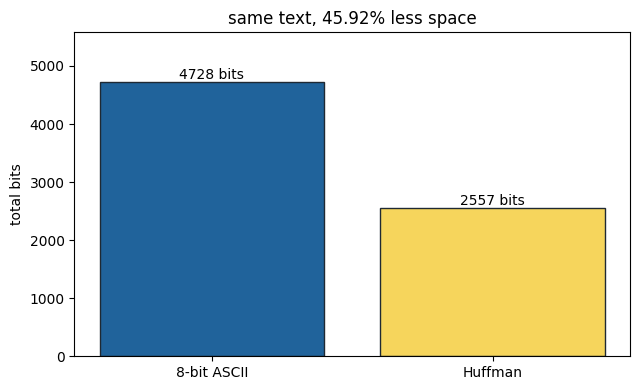

In [7]:
from __future__ import annotations

fig, ax = plt.subplots(figsize=(6.5, 4))
labels = ["8-bit ASCII", "Huffman"]
bit_counts = [report.ascii_bits, report.huffman_bits]
bars = ax.bar(labels, bit_counts, color=["#20639B", "#F6D55C"], edgecolor="#1F2933")

for bar, bits in zip(bars, bit_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bits, f"{bits} bits", ha="center", va="bottom")

ax.set_ylabel("total bits")
ax.set_title(f"same text, {report.percent_saved:.2f}% less space")
ax.set_ylim(0, max(bit_counts) * 1.18)
plt.tight_layout()
plt.show()

## What You Should Remember

- Huffman coding is lossless compression: decoding gives back the exact original text.
- It is greedy: always merge the two least frequent trees.
- The final tree creates a prefix code, so no code is the prefix of another code.
- Frequent characters usually get short codes; rare characters get longer codes.
- Savings are measured by comparing `len(text) * 8` ASCII bits against the Huffman encoded bit string.

<details>
<summary>Quick self-check</summary>

If a character appears many times, a one-bit improvement in its code length saves many total bits. That is why Huffman cares so much about frequency.
</details>

## Visual Trace + Rigor Studio

**Problem frame.** Compress symbols by giving frequent symbols shorter codes.

**Interactive animation target.** Animate the priority queue as the two smallest trees merge into a new tree.

**Correctness handle.** The two least frequent remaining subtrees can be siblings in some optimal prefix code.

**Complexity handle.** O(k log k) for k distinct symbols with a priority queue.

**Failure mode to test.** Huffman coding is optimal for independent symbol frequencies, not for context-dependent language structure.

**Studio task.** Compare a natural-language sample and a uniform sample; explain how the tree shape changes.


In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, AlgorithmTrace, TraceStep, render_trace_table

# Convert the implementation above into snapshots:
# trace = AlgorithmTrace("Topic trace")
# trace.append("start", {"your_state": ...}, "What changed?", invariant="What remains true?")
# AlgorithmPlayer(trace, your_renderer).display()
print("Use AlgorithmTrace to turn this notebook's algorithm into a step-by-step visual player.")
